In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


**intution of how to make a neural network and improve it and how to work with keras library.**

In [12]:
df=pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [13]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
df.shape

(10000, 14)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [16]:
print(df.duplicated().sum())

0


In [17]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [18]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [19]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [20]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [21]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [24]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [25]:
x=df.drop(columns=['Exited'])
y=df['Exited']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [26]:
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [27]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [28]:
x_train.shape

(8000, 11)

In [29]:
x_test.shape

(2000, 11)

In [30]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [31]:
x_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [32]:
x_test_scaled

array([[-1.03768121,  0.77498705, -1.0482813 , ..., -0.58312392,
        -0.57273139,  0.91509065],
       [ 0.30708683, -0.46686456, -0.70174202, ..., -0.58312392,
        -0.57273139,  0.91509065],
       [-1.23422423,  0.29735181, -1.0482813 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       ...,
       [-0.86182692, -0.46686456,  1.72403288, ..., -0.58312392,
         1.74601919,  0.91509065],
       [-0.30323097, -0.84897275, -1.0482813 , ...,  1.71490137,
        -0.57273139, -1.09278791],
       [ 0.04847759,  1.25262228,  1.3774936 , ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [33]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [50]:
model = Sequential()
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [65]:
history=model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8677 - loss: 0.3204 - val_accuracy: 0.8562 - val_loss: 0.3470
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8691 - loss: 0.3201 - val_accuracy: 0.8575 - val_loss: 0.3479
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8684 - loss: 0.3199 - val_accuracy: 0.8569 - val_loss: 0.3467
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8680 - loss: 0.3196 - val_accuracy: 0.8562 - val_loss: 0.3498
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8687 - loss: 0.3200 - val_accuracy: 0.8556 - val_loss: 0.3505
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8694 - loss: 0.3199 - val_accuracy: 0.8587 - val_loss: 0.3494
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8680 - loss: 0.3197 - val_accuracy: 0.8612 - val_loss: 0.3472
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8677 - loss: 0.3194 - val_accu

In [57]:
model.layers[0].get_weights()

[array([[ 0.01088676,  0.02375846,  0.0219079 , -0.19779404, -0.06579736,
          0.42045185, -0.00353334, -0.05229633, -0.22728789,  0.31013328,
          0.00186168],
        [ 0.32298416, -0.7346547 , -0.56579715, -0.48893648,  0.7384007 ,
          0.5976157 ,  1.3557315 ,  0.28198913, -0.11748915, -0.49522856,
         -0.3606425 ],
        [ 0.03578575, -0.23447245,  0.09230081, -0.0031588 ,  0.06818114,
          0.07206233,  0.21219163, -0.06660851, -0.14177361, -0.38362283,
          0.08093783],
        [-0.2106535 ,  0.5452275 , -0.31001934, -1.0030596 , -0.13001868,
          0.54749703, -0.5883134 , -0.06202848, -0.81319374,  0.24092853,
         -0.42968106],
        [-0.04966883, -0.4558313 , -0.03597725, -0.10126938, -0.14575143,
         -0.9157027 , -0.29554412,  1.3576778 , -0.99339795, -0.43309733,
          0.02230067],
        [ 0.13052164,  0.3663503 , -0.10261587,  0.2404299 ,  0.58152956,
          0.02444252, -0.25740615,  0.16040288,  0.11099169,  0.1399895

In [58]:
model.layers[1].get_weights()

[array([[ 0.60432893, -0.5233839 ,  0.48055813, -0.4008156 ,  0.1524411 ,
          0.00285229, -0.292462  ,  0.3359474 , -0.4917147 ,  0.14023167,
          0.6403999 ],
        [ 0.34518558,  0.03292727,  0.03780464,  0.0860343 ,  0.05727434,
          0.27309966, -1.0577233 ,  0.84237117, -0.44098654,  0.01134457,
         -0.46330145],
        [ 0.24398693,  0.20072404,  0.26355544, -0.04491624,  0.6987089 ,
          0.39929444, -0.2512649 , -0.6944367 , -0.24962692, -0.5846694 ,
         -0.6550817 ],
        [ 0.26604617,  0.9093564 ,  0.3090392 ,  1.0221941 , -0.10434694,
          0.50451916, -0.6976413 , -0.33747923, -0.20783831, -0.306711  ,
          0.26187748],
        [ 0.18944733,  0.3695396 ,  0.981931  , -0.00683269, -0.35463277,
         -0.23485631,  0.11166905,  0.19786952, -1.0200479 ,  0.39174533,
         -0.5410279 ],
        [-0.1922997 , -0.09990935, -0.13974218, -0.05706083, -0.04067196,
          0.44320545, -0.42275962,  0.3940233 ,  0.340944  ,  0.3994403

In [59]:
y_log=model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [61]:
y_pred=np.where(y_log>0.5,1,0)

In [62]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [63]:
from sklearn.metrics import accuracy_score

In [64]:
print(accuracy_score(y_test,y_pred))

0.8605


In [67]:
import matplotlib.pyplot as plt

In [68]:
history.history

{'accuracy': [0.8676562309265137,
  0.8690624833106995,
  0.8684375286102295,
  0.867968738079071,
  0.8687499761581421,
  0.8693749904632568,
  0.867968738079071,
  0.8676562309265137,
  0.8678125143051147,
  0.8690624833106995,
  0.8671875,
  0.867968738079071,
  0.8673437237739563,
  0.8692187666893005,
  0.8693749904632568,
  0.8692187666893005,
  0.8678125143051147,
  0.8696874976158142,
  0.8695312738418579,
  0.8696874976158142,
  0.8689062595367432,
  0.870312511920929,
  0.8696874976158142,
  0.8690624833106995,
  0.8682812452316284,
  0.8698437213897705,
  0.8685937523841858,
  0.8684375286102295,
  0.8706250190734863,
  0.8704687356948853,
  0.8693749904632568,
  0.8715624809265137,
  0.8714062571525574,
  0.8700000047683716,
  0.8706250190734863,
  0.8700000047683716,
  0.8685937523841858,
  0.8692187666893005,
  0.8692187666893005,
  0.87109375,
  0.8704687356948853,
  0.8709375262260437,
  0.8712499737739563,
  0.8682812452316284,
  0.87109375,
  0.8700000047683716,
  0.8

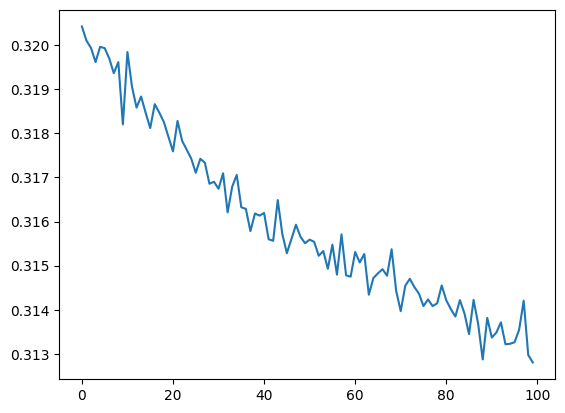

In [69]:
plt.plot(history.history['loss'])

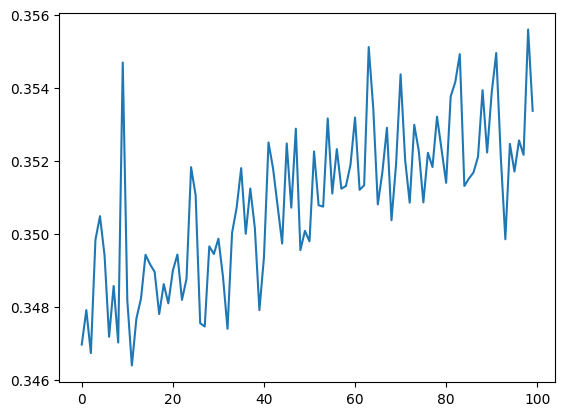

In [70]:
plt.plot(history.history['val_loss'])

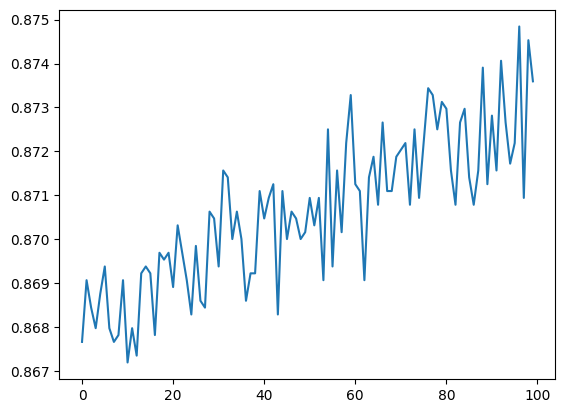

In [71]:
plt.plot(history.history['accuracy'])

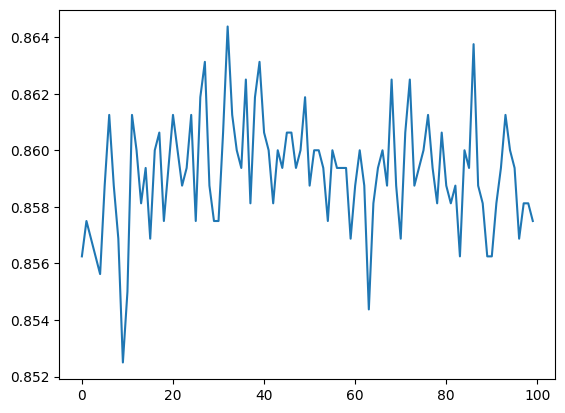

In [72]:
plt.plot(history.history['val_accuracy'])